In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from __future__ import annotations

from offline_opt import StationSpec, compute_offline_bound
from toy_demo.runner import run_toy_episode
from toy_demo.scenario import ToyEVSpec, ToyStationSpec, build_evs

In [3]:
STATION = ToyStationSpec(n_piles=2, n_dispensers=2, n_modules=5, p_module=25.0)

EV_SPECS = [
    ToyEVSpec(id=0, arrival_time=0.0, battery_kwh=50.0, s_i=0.20, s_f=0.80),
    ToyEVSpec(id=1, arrival_time=2.0, battery_kwh=100.0, s_i=0.15, s_f=0.85),
    ToyEVSpec(id=2, arrival_time=8.0, battery_kwh=50.0, s_i=0.25, s_f=0.75),
    ToyEVSpec(id=3, arrival_time=12.0, battery_kwh=150.0, s_i=0.10, s_f=0.80),
    ToyEVSpec(id=4, arrival_time=10.0, battery_kwh=50.0, s_i=0.20, s_f=0.80),
#    ToyEVSpec(id=5, arrival_time=0.0, battery_kwh=50.0, s_i=0.20, s_f=0.80),
#    ToyEVSpec(id=6, arrival_time=0.0, battery_kwh=50.0, s_i=0.20, s_f=0.80),
#    ToyEVSpec(id=7, arrival_time=0.0, battery_kwh=50.0, s_i=0.20, s_f=0.80),
#    ToyEVSpec(id=8, arrival_time=0.0, battery_kwh=50.0, s_i=0.20, s_f=0.80),

]
offline_station = StationSpec(
    n_piles=STATION.n_piles,
    n_dispensers=STATION.n_dispensers,
    n_modules=STATION.n_modules,
    p_module=STATION.p_module,
)

In [22]:
from offline_opt import (
    build_offline_model,
    solve_offline_model,
    extract_solution,
    taper_time_constant,
    vehicles_from_evs,
    default_horizon_minutes,
)

# Built via the lower-level calls (rather than compute_offline_bound) so we
# keep offline_model around -- the plotting functions below read variable
# values (.X) directly off it, which the OfflineSolution summary doesn't expose.
vehicles = vehicles_from_evs(build_evs(EV_SPECS))
tau = taper_time_constant()
horizon = default_horizon_minutes(vehicles, offline_station)
horizon = 30

In [35]:
ip_model = build_offline_model(
    vehicles, offline_station, delta=1, horizon_minutes=horizon, tau=tau,
    tie_break=True,
)
solve_offline_model(ip_model, mip_gap=1e-4, time_limit=300)
ip_sol = extract_solution(ip_model)

In [12]:
a = {j: v.a for j, v in ip_model.vehicles.items()}
# or: offline_model.vehicles[j].a

delta = ip_model.delta
K = ip_model.K

c = {}
for j, v in ip_model.vehicles.items():
    k_j = ip_model.releases[j]
    unfinished = sum(
        1.0 - ip_model.sigma[j, k].X for k in range(k_j, K)
    )
    c[j] = delta * (k_j + unfinished)


sum_sigma = sum(
    ip_model.sigma[j, k].X
    for j in ip_model.vehicles
    for k in range(ip_model.releases[j], K)
)

# or from Gurobi objective when SolCount > 0:
# sum_sigma = offline_model.model.ObjVal
total_sojourn = sum(c[j] - a[j] for j in ip_model.vehicles)

In [41]:

print(f"sum sigma = {sum_sigma:.4f}, and {ip_model.model.ObjVal}")
print(f"sum (c_j - a_j) = {total_sojourn:.4f} min and {ip_sol.total_sojourn}")

sum sigma = 194.0000, and 112.0
sum (c_j - a_j) = 199.0000 min and 112.0


In [42]:
print(f"=== Offline MILP (status={ip_sol.status}, gap={ip_sol.mip_gap:.2%}, runtime={ip_sol.runtime:.1f}s) ===")
print(ip_sol.per_vehicle.to_string(index=False))
print(f"  total sojourn = {ip_sol.total_sojourn:.2f} min\n")

=== Offline MILP (status=OPTIMAL, gap=nan%, runtime=3.5s) ===
 vehicle_id  arrival  pile  service_start  departure  sojourn  finished  energy_kwh  energy_required_kwh
          0      0.0     1              0       26.0     26.0      True   30.000000                 30.0
          1      2.0     0              2       30.0     28.0     False   29.583333                 70.0
          2      8.0     0              8       28.0     20.0      True   25.000000                 25.0
          3     12.0     1             26       30.0     18.0     False    6.250000                105.0
          4     10.0     1             10       30.0     20.0     False   18.333333                 30.0
  total sojourn = 112.00 min



In [25]:
print(f"=== Offline MILP (status={ip_sol.status}, gap={ip_sol.mip_gap:.2%}, runtime={ip_sol.runtime:.1f}s) ===")
print(ip_sol.per_vehicle.to_string(index=False))
print(f"  total sojourn = {ip_sol.total_sojourn:.2f} min\n")

=== Offline MILP (status=OPTIMAL, gap=0.00%, runtime=54.9s) ===
 vehicle_id  arrival  pile  service_start  departure  sojourn  energy_kwh  energy_required_kwh
          0      0.0     1              0       26.0     26.0        30.0                 30.0
          1      2.0     0              2       54.0     52.0        70.0                 70.0
          2      8.0     0              8       28.0     20.0        25.0                 25.0
          3     12.0     1             26       83.0     71.0       105.0                105.0
          4     10.0     1             10       40.0     30.0        30.0                 30.0
  total sojourn = 199.00 min



In [ ]:
from offline_opt import compute_ip_bounds

evs = build_evs(EV_SPECS)

# RP(N*Delta)  <=  IP  <=  RP((N-C+1)*Delta)   [in total_sojourn]
rp_lower, rp_upper = compute_ip_bounds(
    evs,
    offline_station,
    delta=1.0,
    horizon_minutes=horizon,   # same horizon as the IP cell
    mip_gap=1e-4,
    time_limit=300,
)

print("=== Continuous relaxation bounds on IP ===")
print(f"RP lower (full cap {offline_station.n_modules * offline_station.p_module:g} kW): "
      f"{rp_lower.total_sojourn:.3f} min  ({rp_lower.status})")
print(f"IP (integer modules): "
      f"{ip_sol.total_sojourn:.3f} min  ({ip_sol.status})")
print(f"RP upper (reduced cap "
      f"{(offline_station.n_modules - offline_station.n_dispensers + 1) * offline_station.p_module:g} kW): "
      f"{rp_upper.total_sojourn:.3f} min  ({rp_upper.status})")

assert rp_lower.total_sojourn <= ip_sol.total_sojourn + 1e-6
assert ip_sol.total_sojourn <= rp_upper.total_sojourn + 1e-6
print("OK: RP_lower <= IP <= RP_upper")

# print("\n--- RP lower per vehicle ---")
# print(rp_lower.per_vehicle.to_string(index=False))
# print("\n--- RP upper per vehicle ---")
# print(rp_upper.per_vehicle.to_string(index=False))

In [ ]:
from offline_opt import build_relaxed_model, solve_offline_model, extract_solution

full_cap = offline_station.n_modules * offline_station.p_module
reduced_cap = (offline_station.n_modules - offline_station.n_dispensers + 1) * offline_station.p_module

In [ ]:
rp_lo_model = build_relaxed_model(
    vehicles, offline_station, delta=1, horizon_minutes=horizon, tau=tau,
    pile_capacity_kw=full_cap,
)
solve_offline_model(rp_lo_model, mip_gap=1e-4, time_limit=300)
rp_lower = extract_solution(rp_lo_model)
print(f"=== Offline MILP (status={rp_lower.status}, gap={rp_lower.mip_gap:.2%}, runtime={rp_lower.runtime:.1f}s) ===")
print(f"  total sojourn = {rp_lower.total_sojourn:.2f} min\n")

In [ ]:
rp_up_model = build_relaxed_model(
    vehicles, offline_station, delta=1, horizon_minutes=horizon, tau=tau,
    pile_capacity_kw=reduced_cap,
)
solve_offline_model(rp_up_model, mip_gap=1e-4, time_limit=300)
rp_upper = extract_solution(rp_up_model)
print(f"=== Offline MILP (status={rp_upper.status}, gap={rp_upper.mip_gap:.2%}, runtime={rp_upper.runtime:.1f}s) ===")
print(f"  total sojourn = {rp_upper.total_sojourn:.2f} min\n")

In [26]:
from offline_opt import plot_vehicle_power_and_modules
import matplotlib.pyplot as plt

# One figure per vehicle id: power drawn each slot (bars, straight off the
# solved MILP's p[j,k]), the reconstructed BMS max request (dashed, left
# axis), and modules assigned (dashed step, right axis, sum_m b[j,m,k]).
figs = plot_vehicle_power_and_modules(
    ip_model,
    vehicle_ids=[0, 1, 2, 3, 4],   # <- enter any subset of vehicle ids here
    show_bms_request=True,
    show_modules=True,
    bar_width=0.9,
)


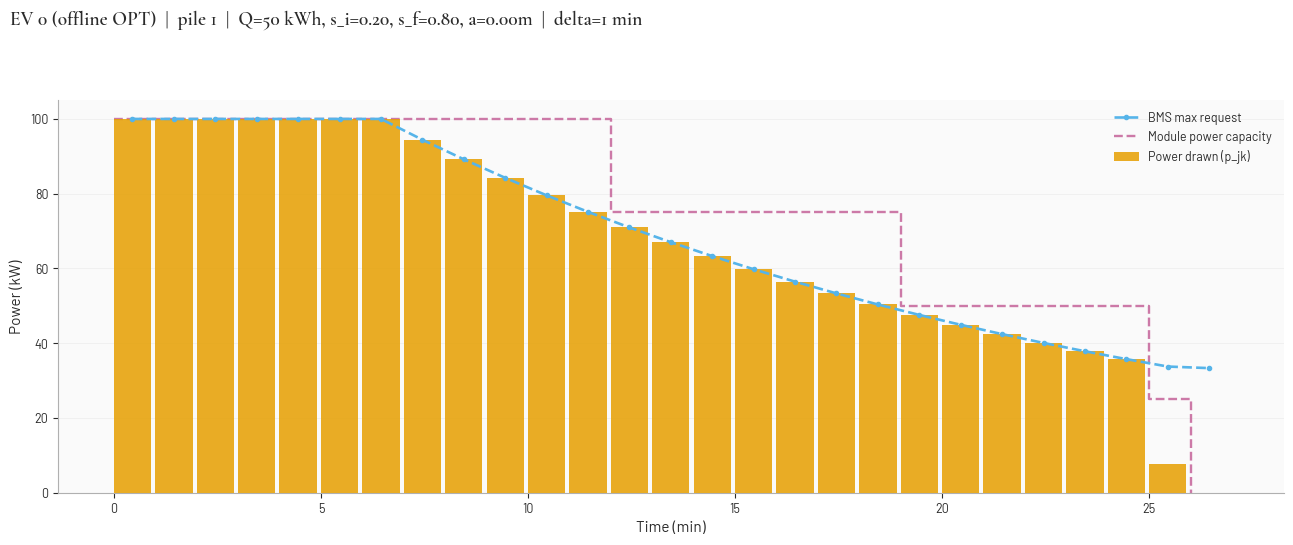

In [27]:
figs[0]

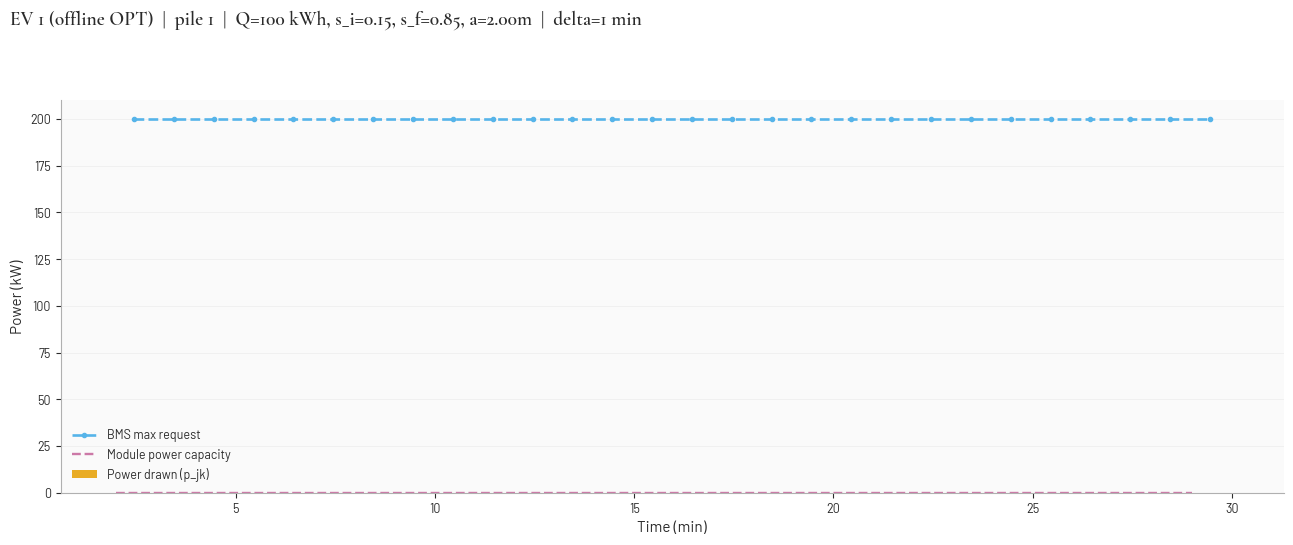

In [40]:
figs[1]

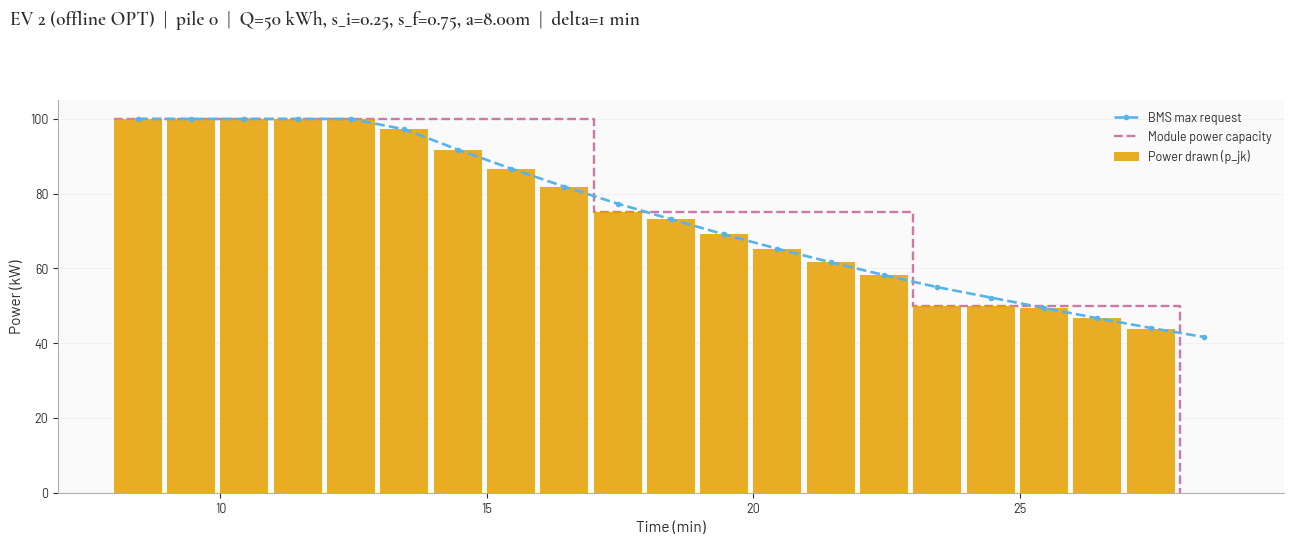

In [39]:
figs[2]

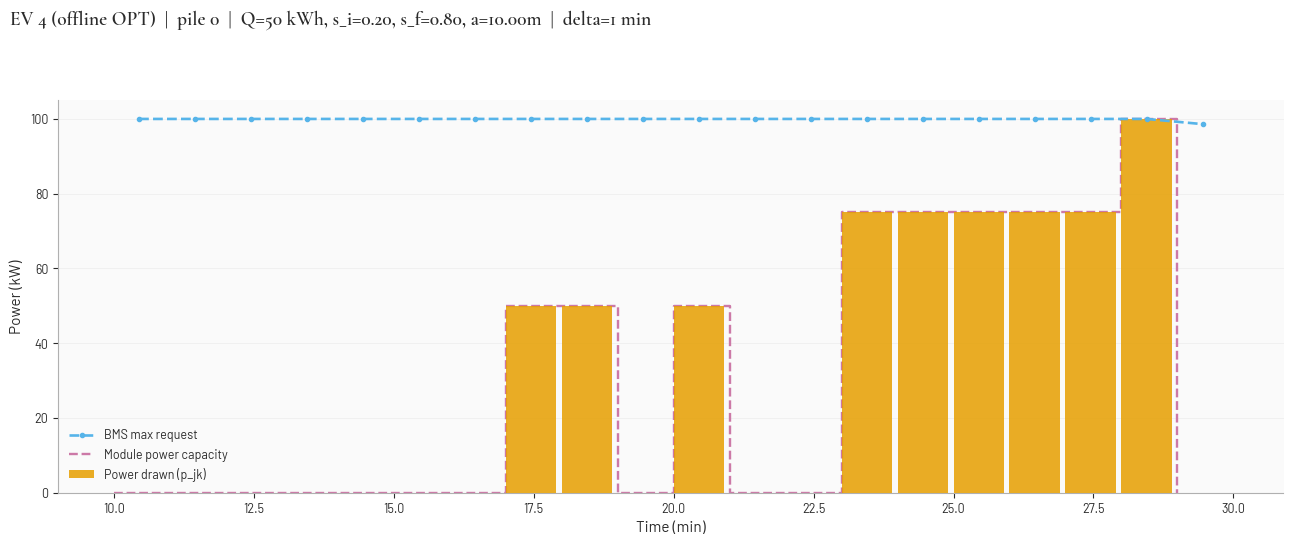

In [38]:
figs[4]

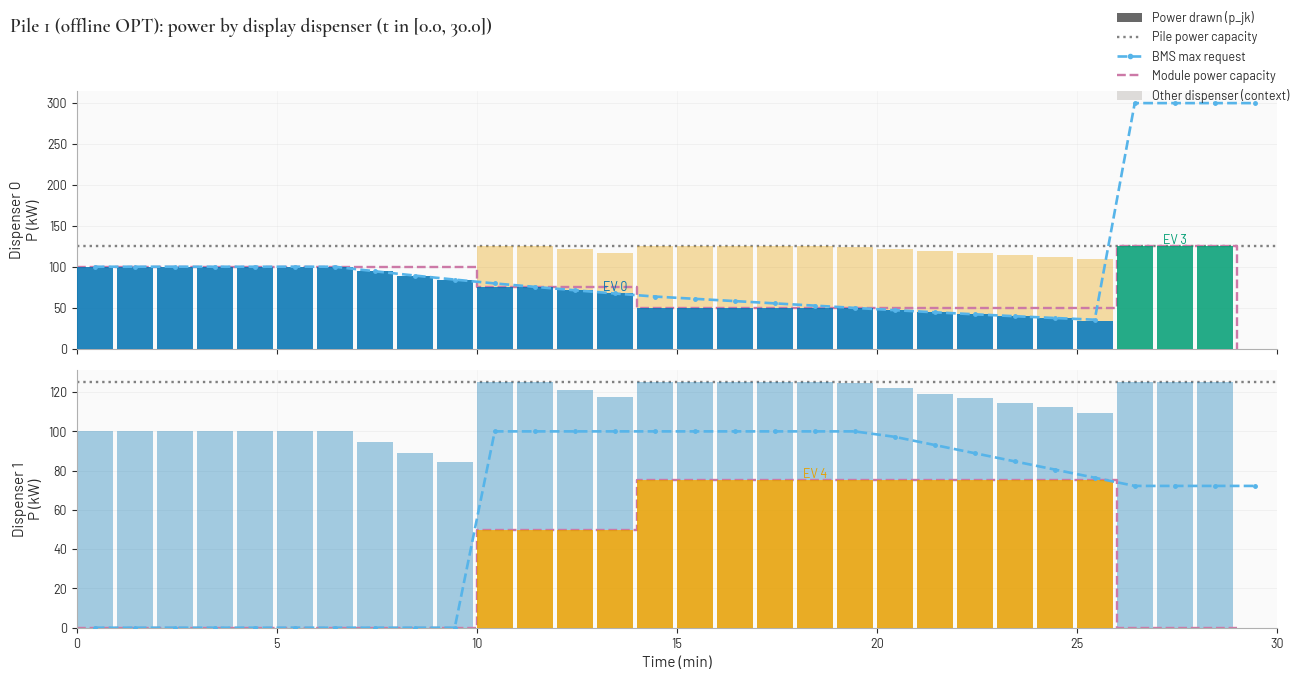

In [37]:
from offline_opt import plot_pile_power_and_modules
import matplotlib.pyplot as plt

# One figure per pile id: one subplot per *display* dispenser (the MILP only
# decides pile assignment + dispenser count per slot, not dispenser identity --
# see offline_opt/visualization.py's module docstring for how dispensers are
# assigned for display). Each subplot bars its occupant's power drawn per
# slot, BMS max request (dashed), and modules assigned (dashed, right axis).
# Call once per pile id you want to see.
fig = plot_pile_power_and_modules(
    ip_model,
    pile_id=1,                    # <- enter a pile id here
    t_start=None,                  # <- enter a time-window subset (None -> actual activity on this pile)
    t_end=None,
    stack_other_dispensers=True,     # toggle: stack other dispensers' power on top
    other_alpha=0.35,             #         (same pile, low alpha, for context)
    show_bms_request=True,
    show_modules=True,
    bar_width=0.9,
    show_ev_ids=True,
    show_pile_capacity=True
)
fig

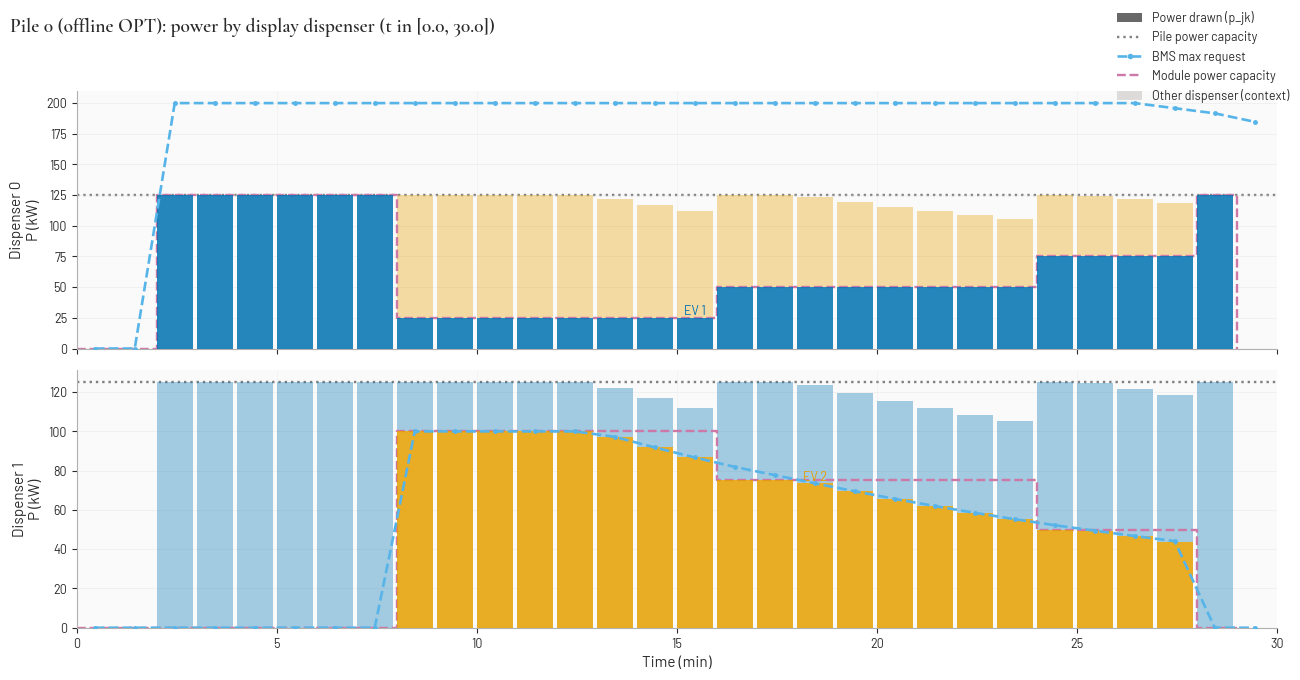

In [36]:
from offline_opt import plot_pile_power_and_modules
import matplotlib.pyplot as plt

# One figure per pile id: one subplot per *display* dispenser (the MILP only
# decides pile assignment + dispenser count per slot, not dispenser identity --
# see offline_opt/visualization.py's module docstring for how dispensers are
# assigned for display). Each subplot bars its occupant's power drawn per
# slot, BMS max request (dashed), and modules assigned (dashed, right axis).
# Call once per pile id you want to see.
fig = plot_pile_power_and_modules(
    ip_model,
    pile_id=0,                    # <- enter a pile id here
    t_start=None,                  # <- enter a time-window subset (None -> actual activity on this pile)
    t_end=None,
    stack_other_dispensers=True,     # toggle: stack other dispensers' power on top
    other_alpha=0.35,             #         (same pile, low alpha, for context)
    show_bms_request=True,
    show_modules=True,
    bar_width=0.9,
    show_ev_ids=True,
    show_pile_capacity=True
)
fig